# South Qoroq ca. 1163 Ma paleomagnetic pole

## Geologic Context

- Terrane: Laurentia-Greenland.
- Compiled unit/pole label: South Qoroq Intr.

## Paleomagnetic And Rock Magnetic Data

- B = 9 sites, N = 67 samples; mean direction DEC/INC = 299.9°/51.2°; K = 20.0.
- Rock-magnetic interpretation: expand with mineral carriers/coercivity/unblocking evidence from source studies.

## Age Constraints

- Current bracket: nominal age 1163 Ma, lomagage 1161 Ma, himagage 1165 Ma.
- Compilation method note: This is considered a younger giant dike from the Tugtutôq region with a 1163 ± 2 Ma U-Pb baddeleyite age unpublished from Heaman.

## References

- Paleomagnetic source: Piper, J.D.A. (1992). The palaeomagnetism of major (Middle Proterozoic) igneous complexes, South Greenland and the Gardar apparent polar wander track. *Precambrian Research*, 54, 153–172.
- Geochronology / age-constraint note (compilation): Upton, B. G. J. (2013). Tectono-magmatic evolution of the younger Gardar southern rift, South Greenland. *Geological Survey of Denmark and Greenland Bulletin*, 29, 1–124. https://doi.org/10.34194/geusb.v29.4692

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Pole from the Evans et al. (2021) compilation

The pole is read directly from the previous Nordic compilation (`data/Evans_et_al_2021_compilation.csv`). No site-level recomputation is performed because the underlying directions are not digitized in this repository; the published pole is carried forward into the Nordic compilation format.

In [2]:
evans = pd.read_csv('../data/Evans_et_al_2021_compilation.csv')
row = evans[evans['ROCKNAME'] == 'South Qoroq Intr.'].iloc[0]

pole_mean = {'dec': float(row['PLONG']), 'inc': float(row['PLAT']),
             'alpha95': float(row['A95']), 'n': int(float(row['B']))}
dir_mean = {'dec': float(row['DEC']), 'inc': float(row['INC']),
            'alpha95': float(row['ED95']), 'k': float(row['KD'])}

print('South Qoroq Intrusion' + ' pole (Evans et al., 2021 compilation):')
print(f"  PLAT {pole_mean['inc']}  PLON {pole_mean['dec']}  A95 {pole_mean['alpha95']}  B {pole_mean['n']} sites")
print(f"  mean direction Dec {dir_mean['dec']}  Inc {dir_mean['inc']}  (%REV {row['%REV']})")

South Qoroq Intrusion pole (Evans et al., 2021 compilation):
  PLAT 41.8  PLON 215.9  A95 13.1  B 9 sites
  mean direction Dec 299.9  Inc 51.2  (%REV 0or100)


## Statistical assessment (Meert et al., 2020; R2)

In [3]:
pt.R2_test('South Qoroq Intr.', Laurentia_poles)

N = 67 (N ≥ 25; sufficient sample number);
B = 9 (B ≥ 8; sufficient site number);
K = 20 (70 ≥ K ≥ 10; meets PSV criteria);
A_95 of 13.1 passes Deenen et al. (2011) criteria of being between 5.0 and 20.5 for this number of sites


## Euler rotation into the Laurentia reference frame

These rocks belong to the Laurentia-Greenland terrane, so the pole must be restored into the Laurentia reference frame before it is compared with the Laurentia APWP. The Greenland-to-Laurentia rotation of Roest & Srivastava (1989), associated with Cenozoic opening of Baffin Bay and the Labrador Sea, is applied with `pmag.pt_rot`: Euler pole 67.5 deg N / -118.5 deg E, angle -13.8 deg. This is the same rotation `get_Laurentia_poles` uses to place the Greenland comparison poles into Laurentia coordinates.

In [4]:
euler_greenland = pt.TERRANE_EULER_POLES['Laurentia-Greenland']   # [67.5, -118.5, -13.8]; Roest & Srivastava (1989)
rlat, rlon = pmag.pt_rot(euler_greenland, [pole_mean['inc']], [pole_mean['dec']])
pole_rotated = {'inc': rlat[0], 'dec': rlon[0], 'alpha95': pole_mean['alpha95']}
print(f"unrotated (present-day Greenland frame): {pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E")
print(f"rotated into the Laurentia frame:        {pole_rotated['inc']:.1f} N / {pole_rotated['dec']:.1f} E")

unrotated (present-day Greenland frame): 41.8 N / 215.9 E
rotated into the Laurentia frame:        44.4 N / 207.4 E


## Position within the Laurentia apparent polar wander path

The pole is shown in its unrotated position (present-day Greenland coordinates, off the Laurentia path) and rotated into the Laurentia frame (restored onto the path). The comparison APWP poles are all shown in Laurentia coordinates.

posx and posy should be finite values
posx and posy should be finite values


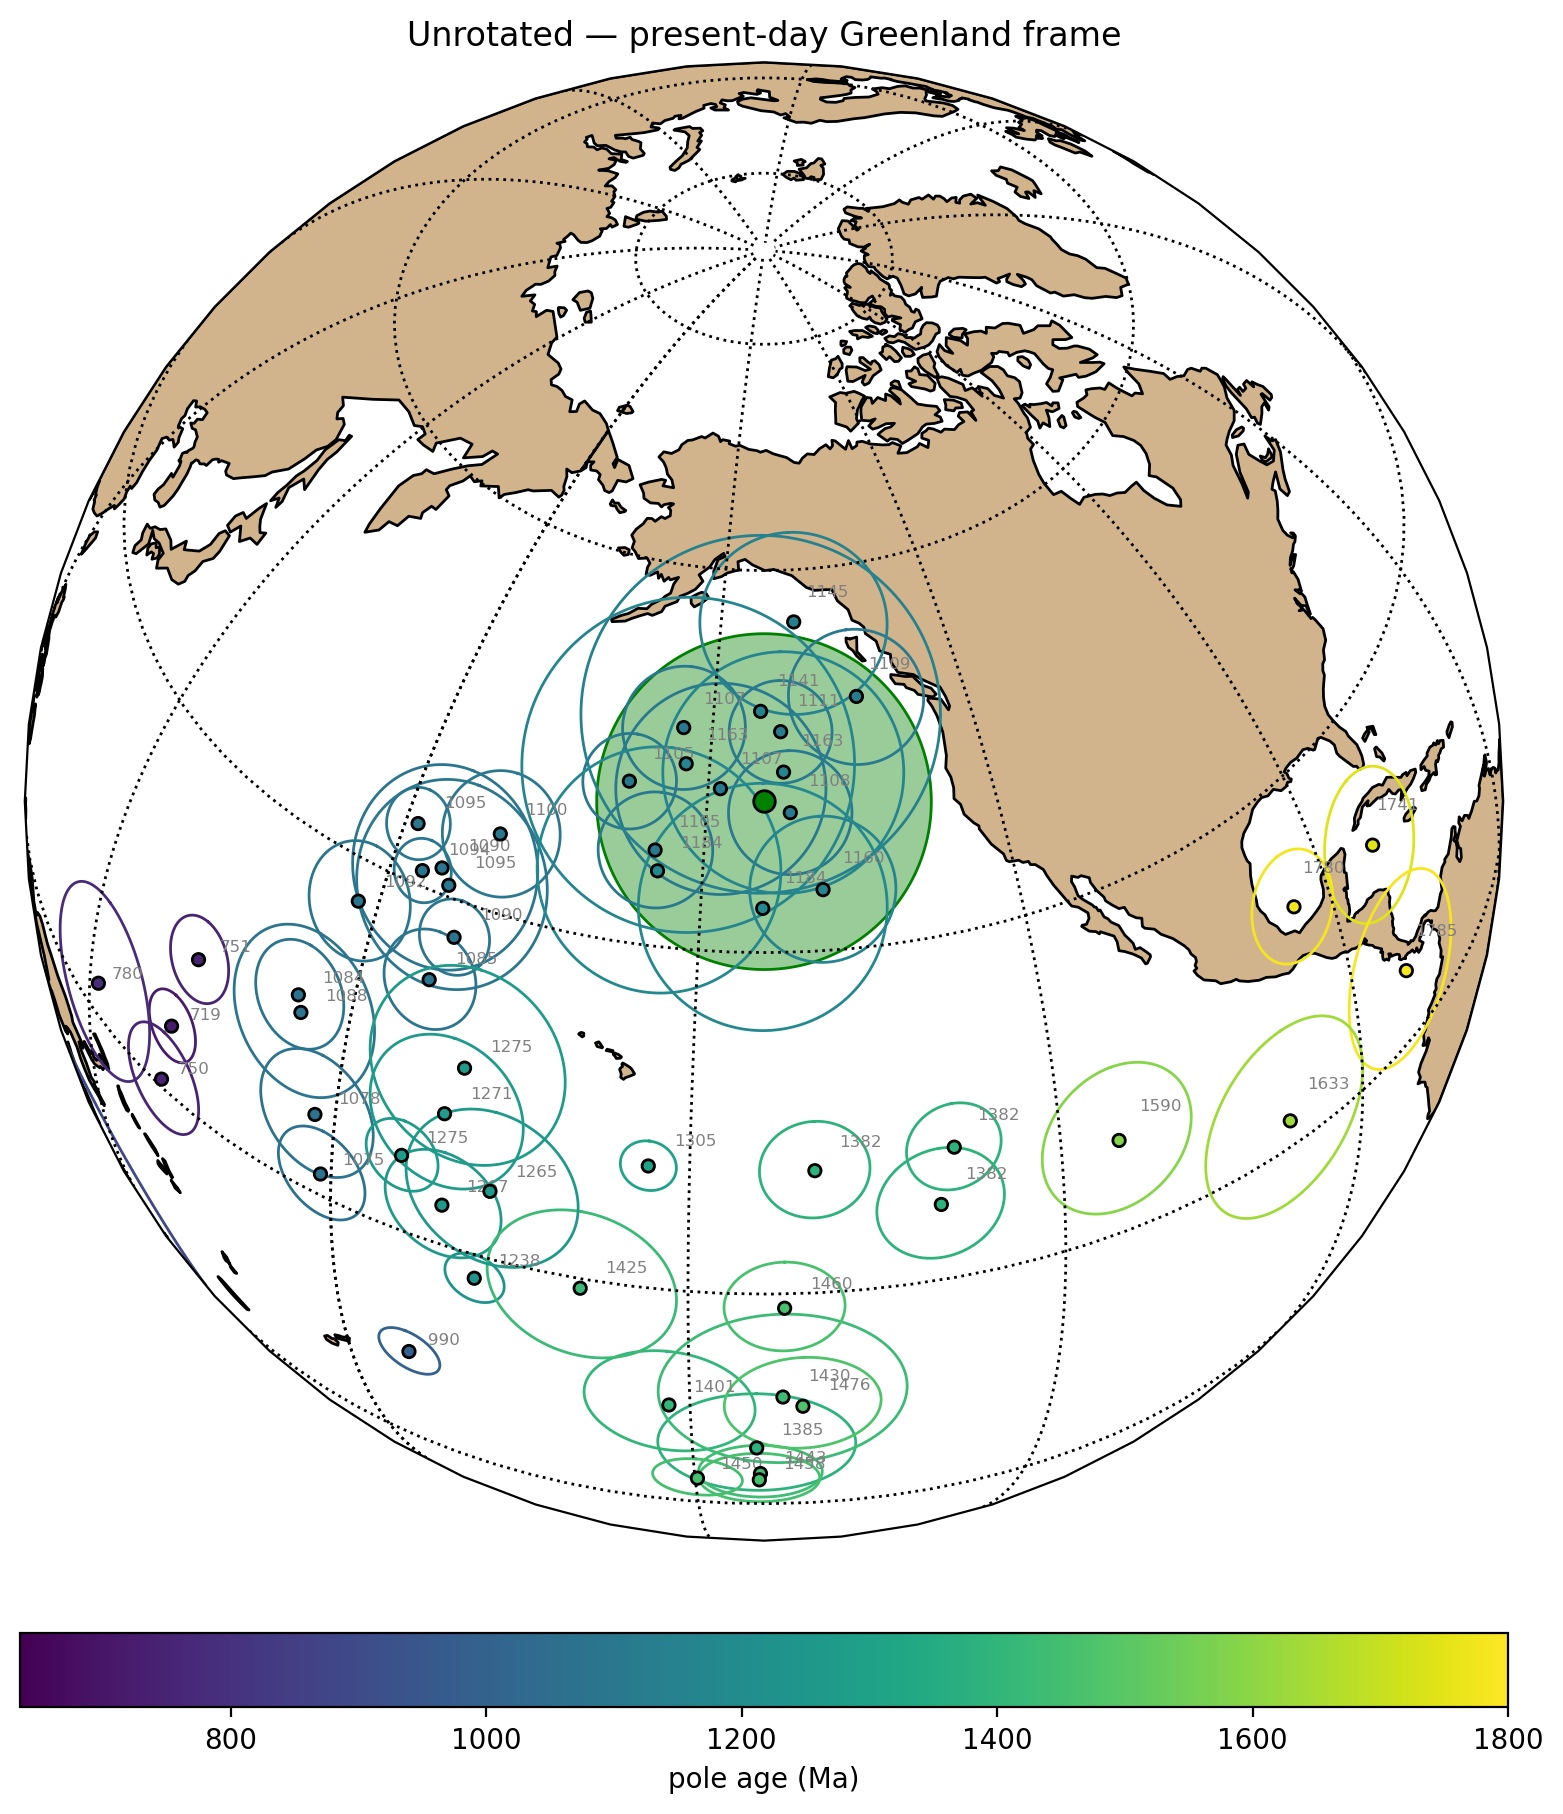

In [5]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

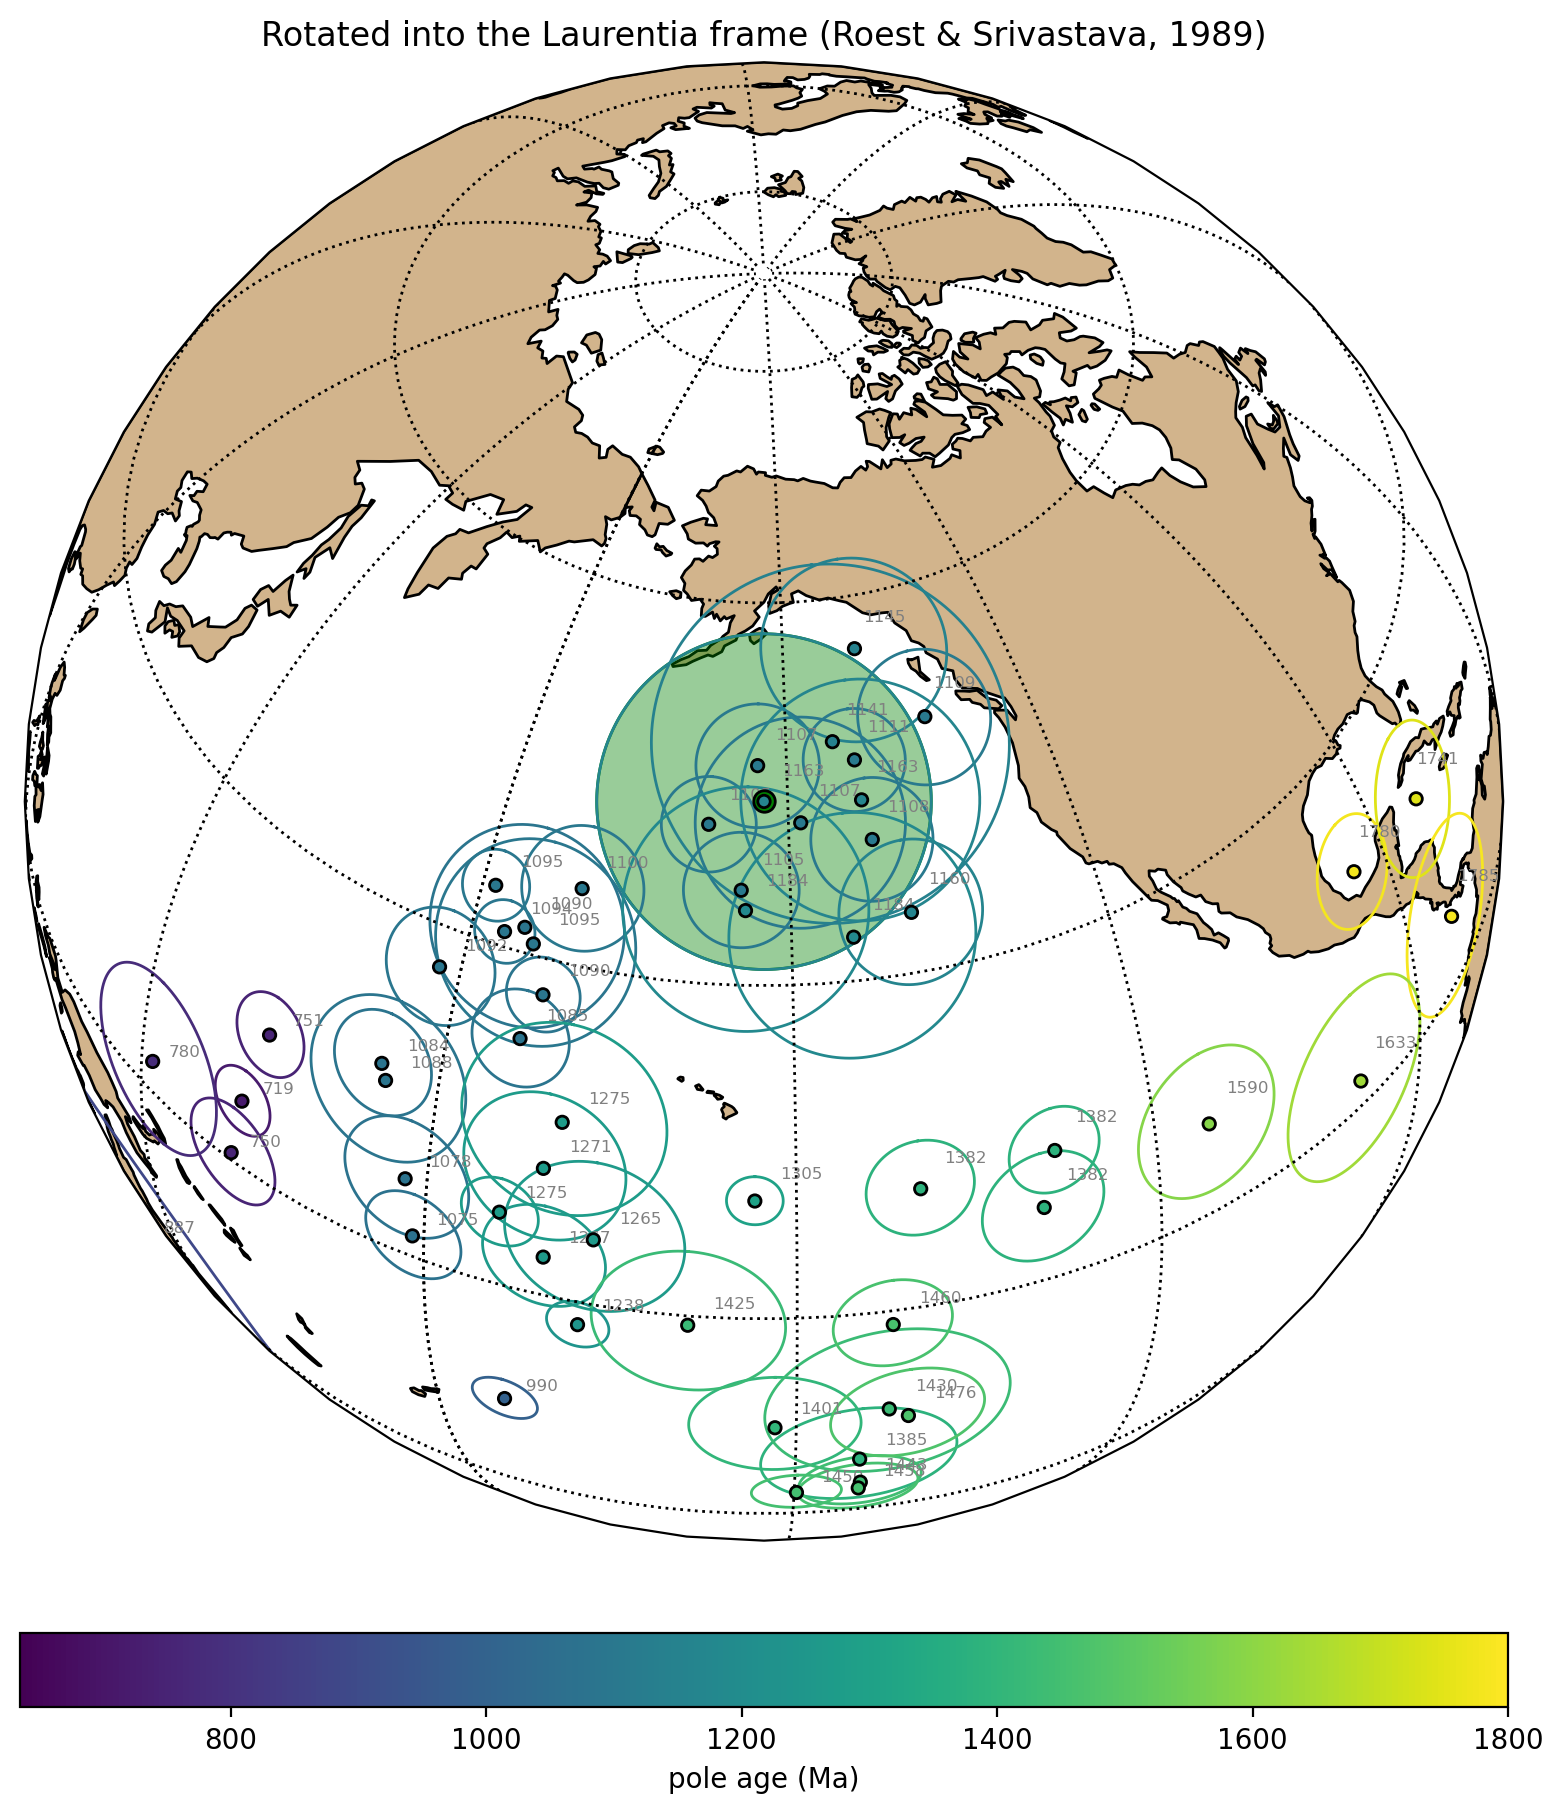

In [6]:
ax = pt.plot_apwp_context(Laurentia_poles, pole_rotated['inc'], pole_rotated['dec'],
                          pole_rotated['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_rotated['dec'],
                          central_latitude=pole_rotated['inc'])
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Comparison with younger Laurentia poles

The `plot_pole_overlap` comparison is shown for both the unrotated and the rotated position.

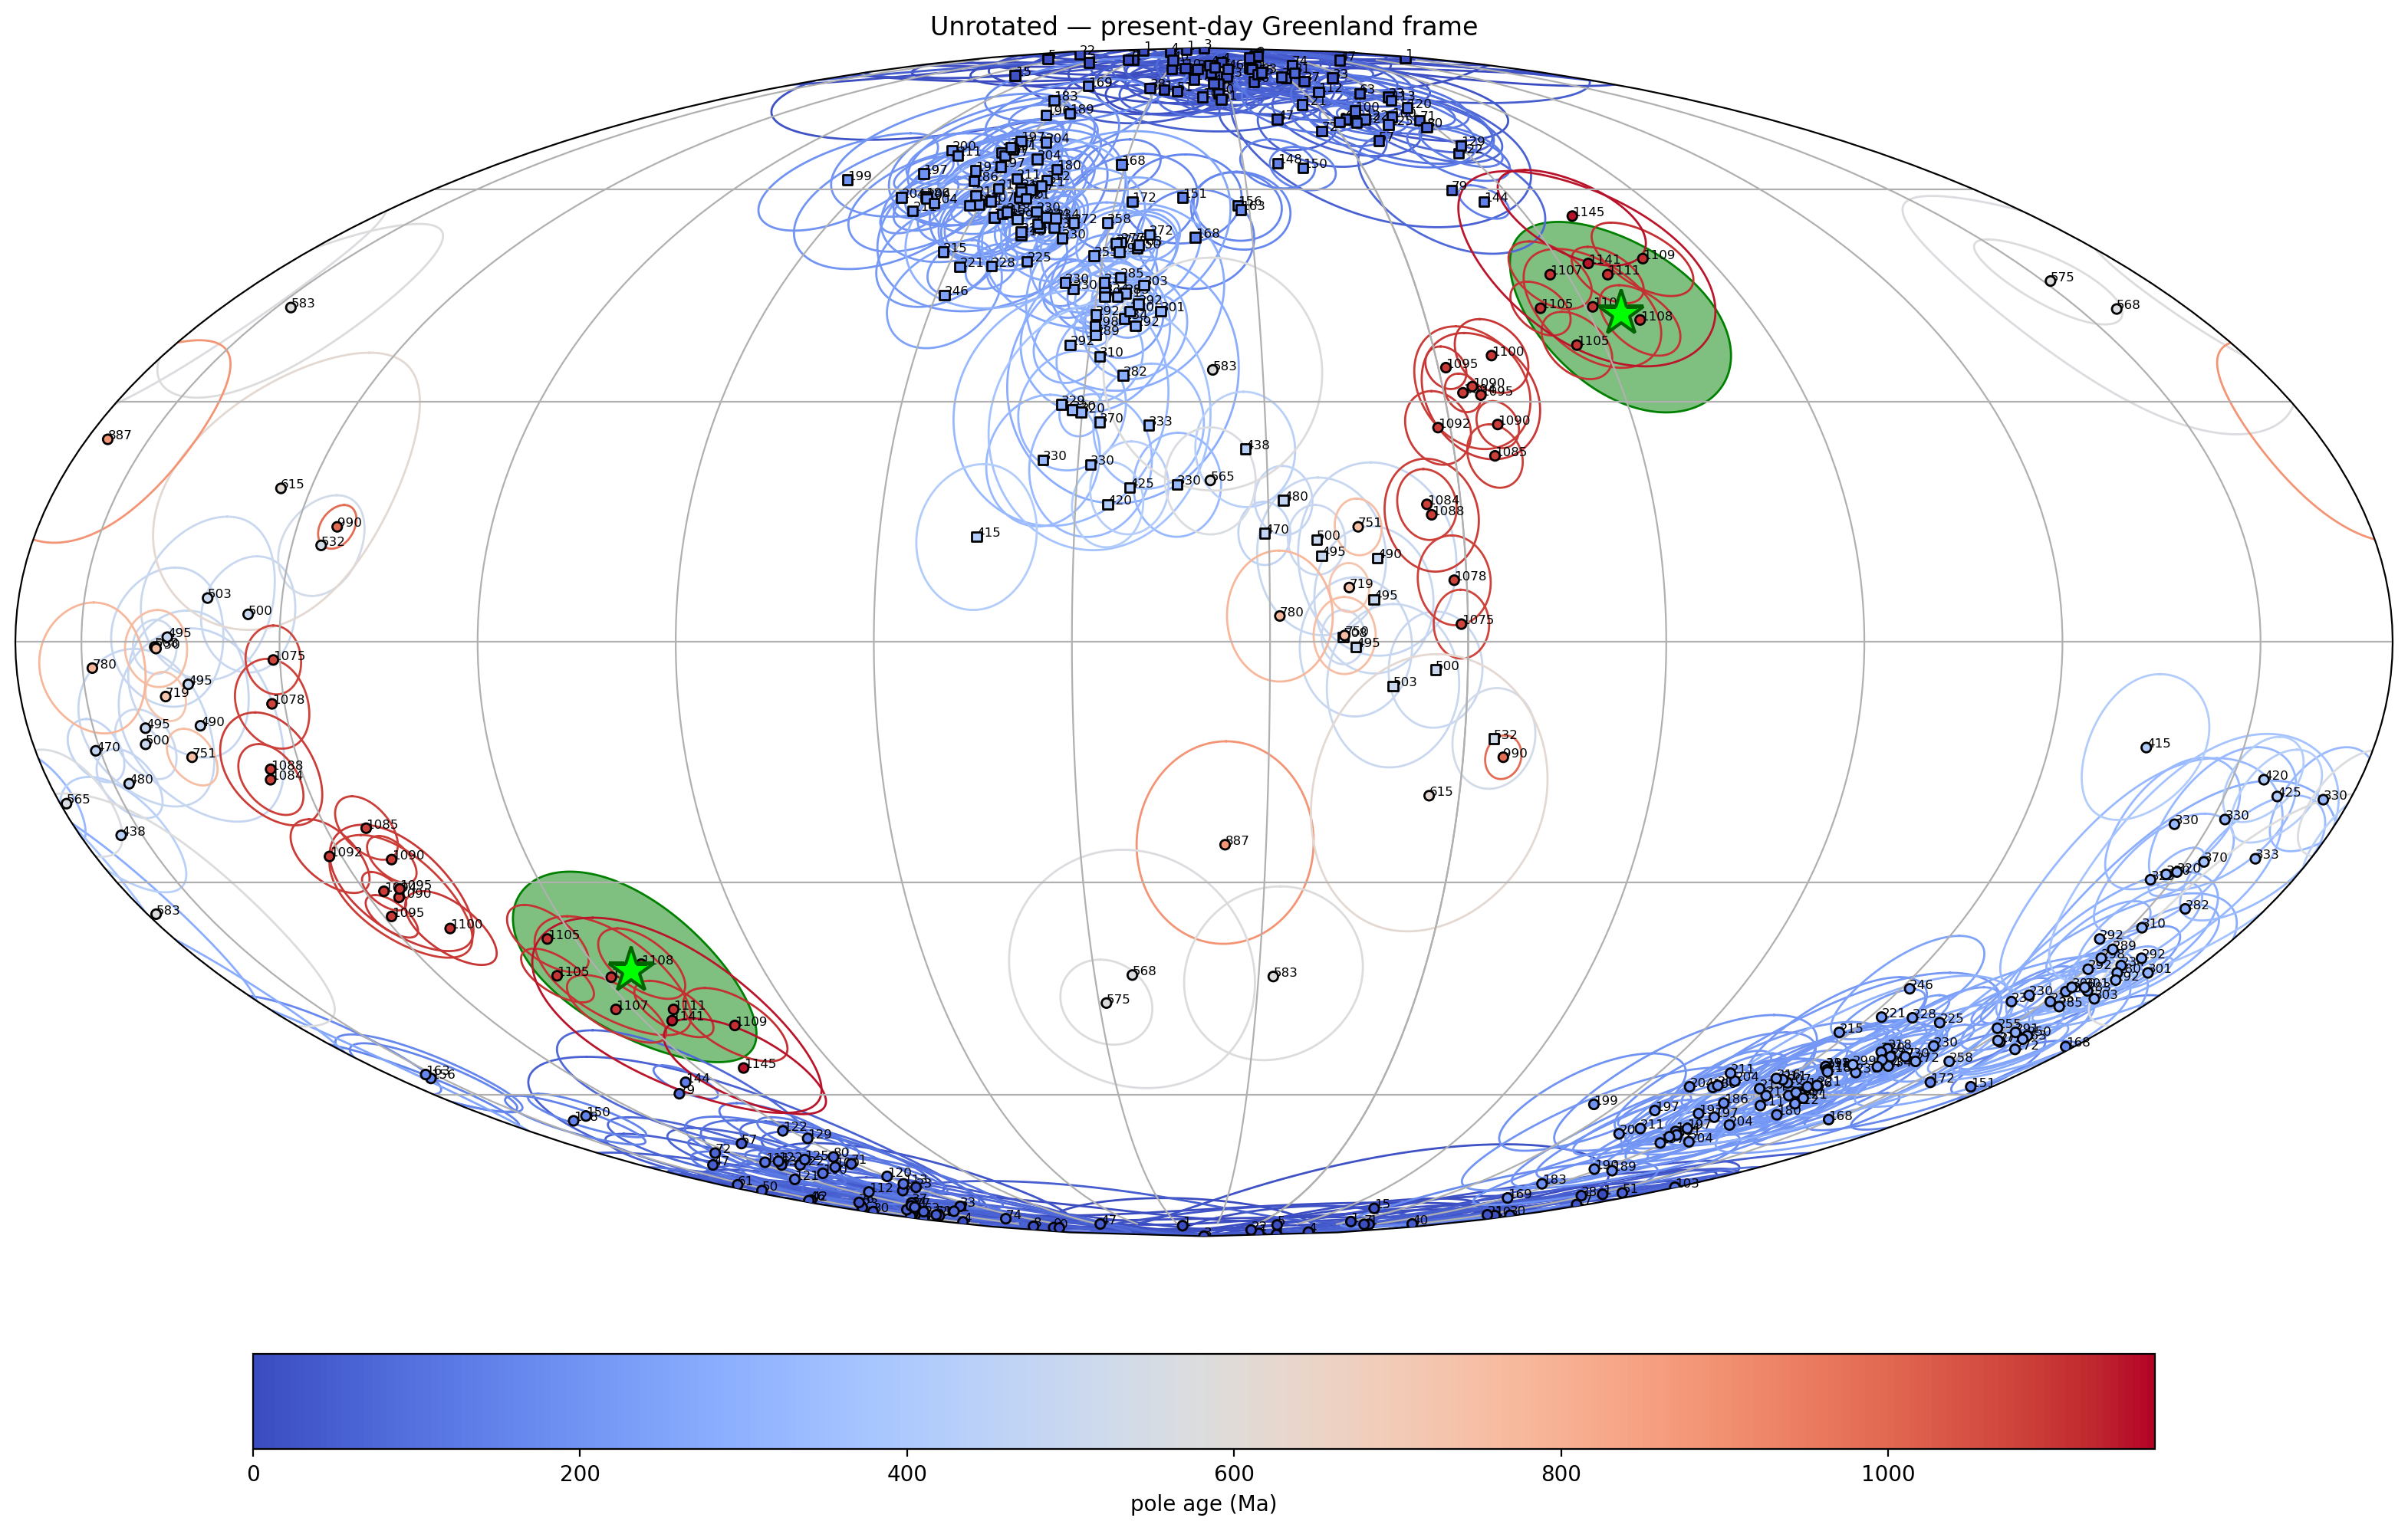

In [7]:
pt.plot_pole_overlap('South Qoroq Intr.', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1163, show=False)
plt.title('Unrotated \u2014 present-day Greenland frame')
plt.show()

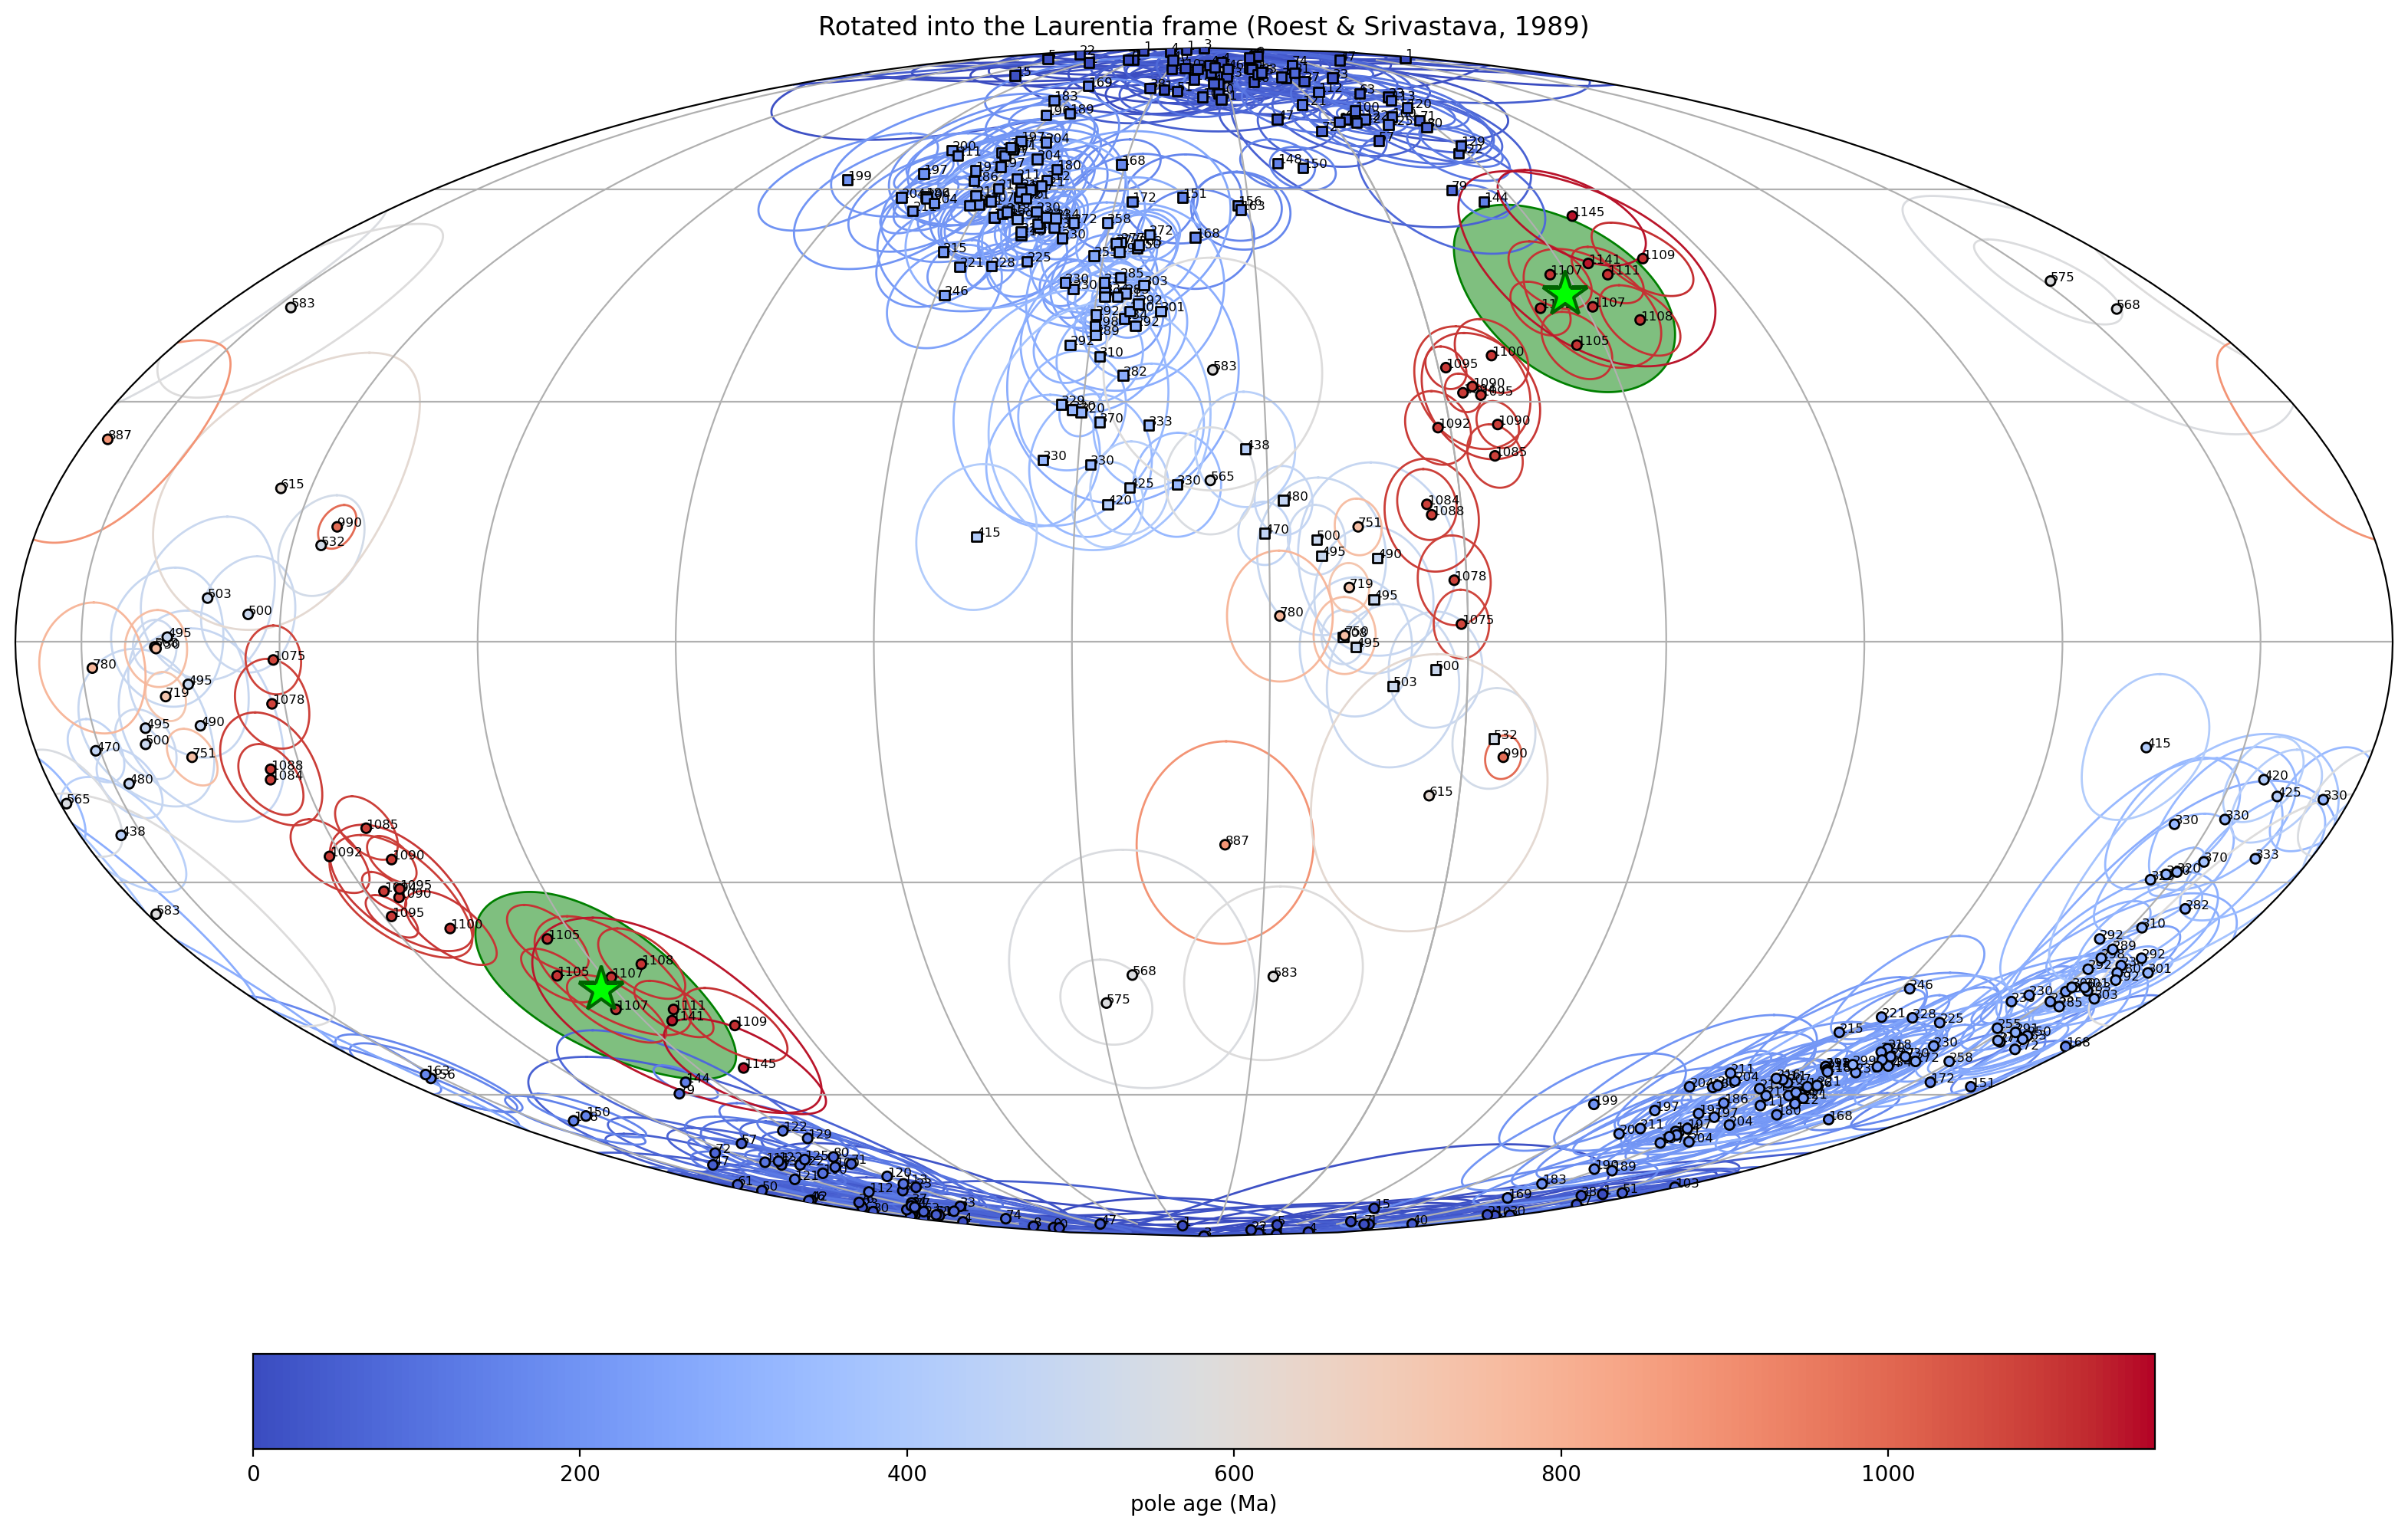

In [8]:
pt.plot_pole_overlap('South Qoroq Intr.', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_rotated['inc'], pole_plon=pole_rotated['dec'],
                     pole_A95=pole_rotated['alpha95'], pole_age=1163, show=False)
plt.title('Rotated into the Laurentia frame (Roest & Srivastava, 1989)')
plt.show()

## Nordic workshop summary

The pole is exported in the Nordic compilation format. The R-criteria scores, pole position, mean direction, and source-publication metadata are carried from the Evans et al. (2021) compilation; the nominal age, age bounds (lomagage/himagage), and the compilation method note are taken from the age-constraint section of the first markdown cell. The pole is exported in its unrotated, present-day Greenland coordinates; the rotation into the Laurentia frame is applied above only for the APWP comparison.

In [9]:
R2, R3, R5, R6, R7 = (int(float(row[k])) for k in ['2', '3', '5', '6', '7'])
R4 = 'C' if float(row['4']) != 0 else ''

sites = pd.DataFrame([{'dir_tilt_correction': int(float(row['TILT'])),
                       'dir_n_samples': int(float(row['N']))}])

summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='South Qoroq Intrusion',
    sites=sites,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=float(row['SLONG']),
    study_lat=float(row['SLAT']),
    component_comment='Characteristic remanent magnetization; mean for the South Qoroq intrusion (Gardar Province, South Greenland)',
    tests='',
    gpmdb_number='',
    magic_id='',
    percent_reversed='',
    demag_code='',
    R1=1, R2=R2, R3=R3, R4=R4, R5=R5, R6=R6, R7=R7, Grade=row['Grade'],
    nominal_age=1163, lomagage=1161, himagage=1165,
    REF_method='1160 +/- 8 Ma Rb-Sr, and a 1163 +/- 2 Ma U-Pb age on the associated younger giant dykes (as compiled by Evans et al., 2021).',
    POLE_AUTHORS=row['POLE AUTHORS'],
    YEAR=int(float(row['YEAR'])),
    JOURNAL=row['JOURNAL'],
    VOLUME=str(row['VOLUME']),
    VPAGES=str(row['VPAGES']),
    TITLE=row['TITLE'],
    COMMENT='Pole taken from the Evans et al. (2021) Laurentia compilation (Piper, 1992); no site-level directions digitized here. Source compilation lists %REV as 0or100 (ambiguous polarity assignment). Nominal age, age bounds, and the compilation method note are carried from the notebook age-constraint section.'
)
pt.save_nordic_summary(summary, '1163_South_Qoroq')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,South Qoroq Intrusion,,Characteristic remanent magnetization; mean fo...,,0,61.2,314.6,9,67,...,1165,"1160 +/- 8 Ma Rb-Sr, and a 1163 +/- 2 Ma U-Pb ...",South Qoroq Intrusion,"Piper, J.D.A.",1992,Precambrian Res.,54,153-172,The palaeomagnetism of major (Middle Proterozo...,Pole taken from the Evans et al. (2021) Lauren...
